In [18]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, Sequential
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
import os

In [2]:
model = models.load_model("model_59.keras")

In [4]:
batch_size = 32
img_height = 180
img_width = 180

In [7]:
data_dir = "fish_dataset/inat_fish_dataset"
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 6012 files belonging to 200 classes.
Using 4810 files for training.


In [8]:
class_names = train_ds.class_names
print(class_names)

['Abudefduf_saxatilis', 'Abudefduf_sexfasciatus', 'Abudefduf_sordidus', 'Abudefduf_troschelii', 'Abudefduf_vaigiensis', 'Acanthopagrus_australis', 'Acanthurus_coeruleus', 'Acanthurus_lineatus', 'Acanthurus_nigrofuscus', 'Acanthurus_sandvicensis', 'Acanthurus_tractus', 'Acanthurus_triostegus', 'Achoerodus_viridis', 'Aluterus_scriptus', 'Ambloplites_rupestris', 'Ameiurus_melas', 'Ameiurus_natalis', 'Ameiurus_nebulosus', 'Amphiprion_clarkii', 'Amphiprion_ocellaris', 'Anguilla_rostrata', 'Aplodinotus_grunniens', 'Aracana_ornata', 'Archosargus_probatocephalus', 'Ariopsis_felis', 'Arothron_hispidus', 'Arothron_meleagris', 'Arothron_nigropunctatus', 'Aulostomus_chinensis', 'Aulostomus_maculatus', 'Balistapus_undulatus', 'Balistoides_viridescens', 'Brevoortia_tyrannus', 'Campostoma_anomalum', 'Canthigaster_valentini', 'Caranx_melampygus', 'Caranx_ruber', 'Carassius_auratus', 'Carassius_gibelio', 'Catostomus_commersonii', 'Cephalopholis_argus', 'Chaetodon_auriga', 'Chaetodon_capistratus', 'Chae

In [27]:
local_path = os.path.abspath("./fish_dataset/inat_fish_dataset/Pimephales_notatus/00005_b363e66e86.jpg")
url = "file://" + local_path
# img_path = tf.keras.utils.get_file('Chrysophrys_auratus', origin=url)

img = tf.keras.utils.load_img(
    local_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
This image most likely belongs to Phyllopteryx_taeniolatus with a 9.99 percent confidence.


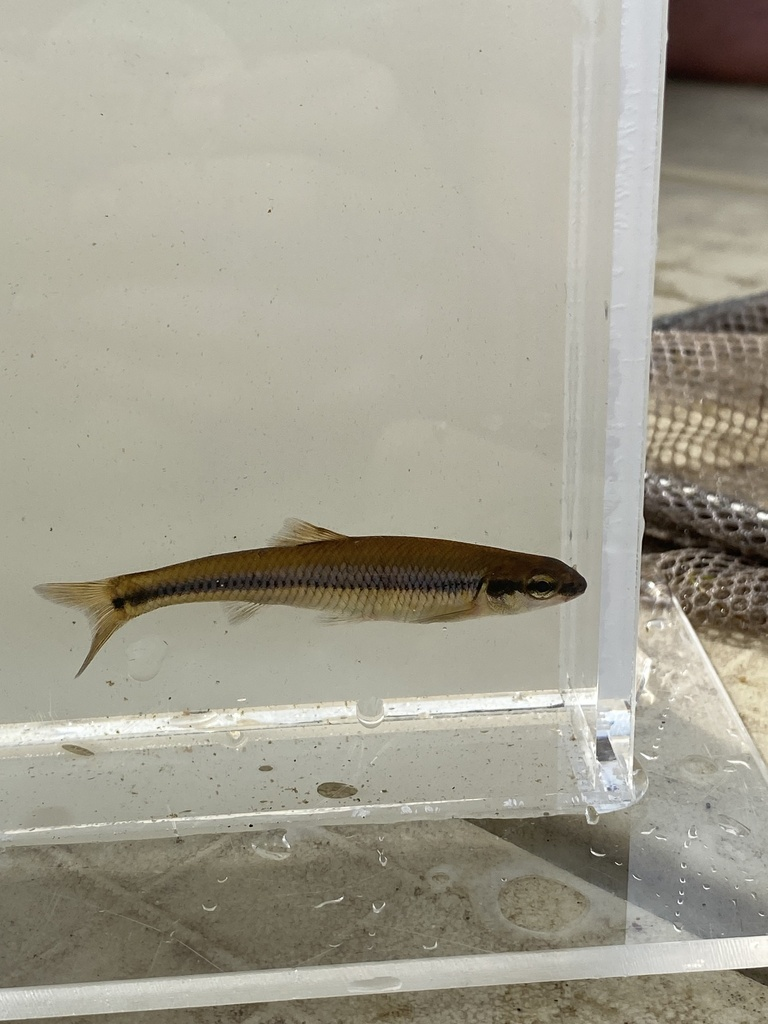

In [26]:
img = Image.open(local_path)
img